# Practice 3: Loan Approval Risk Model

# 0 — Notebook Setup

In [12]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import sklearn
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Optional display settings
pd.set_option("display.max_columns", None)

# 1 Data Loading and Business Understanding

## STEP 1.1 — Load Dataset

In [13]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Column names (official description)
columns = [
    "checking_status", "duration", "credit_history", "purpose",
    "credit_amount", "savings_status", "employment",
    "installment_commitment", "personal_status", "other_parties",
    "residence_since", "property_magnitude", "age",
    "other_payment_plans", "housing", "existing_credits",
    "job", "num_dependents", "own_telephone", "foreign_worker",
    "target"
]

df = pd.read_csv(url, sep=" ", header=None)
df.columns = columns

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [14]:
print("Shape:", df.shape)

Shape: (1000, 21)


In [15]:
# Convert target: 1 -> 0 (good), 2 -> 1 (bad)
df["target"] = df["target"].map({1: 0, 2: 1})

df["target"].value_counts()

target
0    700
1    300
Name: count, dtype: int64

In [16]:
df["target"].value_counts(normalize=True)

target
0    0.7
1    0.3
Name: proportion, dtype: float64

- 0 = Good  
- 1 = Bad

## Task 1.2 — Business Interpretation

In banking, a **default (bad risk)** means that a customer fails to repay the loan according to the agreed contract. This can result in financial loss for the bank due to unpaid principal, interest, and recovery costs.

There are two types of prediction mistakes:

- False Negative (FN): The model predicts good, but the client is actually bad.  
    → The bank approves a risky client and may lose money.  
    👉 This is usually the most expensive mistake.

- False Positive (FP): The model predicts bad, but the client is actually good.  
    → The bank rejects a reliable customer.  
    👉 This means lost business opportunity and potential reputation damage.

In credit risk modeling, **False Negatives are typically more dangerous than False Positives**, because approving bad clients directly creates financial loss.

# 2  Data Quality and Simple EDA

## Task 2.1 — Missing Values & Data Types

In [17]:
# Check missing values
df.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
target                    0
dtype: int64

In [18]:
df.dtypes

checking_status             str
duration                  int64
credit_history              str
purpose                     str
credit_amount             int64
savings_status              str
employment                  str
installment_commitment    int64
personal_status             str
other_parties               str
residence_since           int64
property_magnitude          str
age                       int64
other_payment_plans         str
housing                     str
existing_credits          int64
job                         str
num_dependents            int64
own_telephone               str
foreign_worker              str
target                    int64
dtype: object

In [19]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "str"]).columns.tolist()
numeric_features.remove("target")
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categorical features:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [20]:
print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 7
Categorical: 13


## Task 2.2 — Correlation Analysis

In [21]:
# Correlation matrix for numeric features + target
corr_matrix = df[numeric_features + ["target"]].corr()

corr_matrix

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,target
duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834,0.214927
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142,0.154739
installment_commitment,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207,0.072404
residence_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643,0.002967
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201,-0.091127
existing_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667,-0.045732
num_dependents,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000,-0.003015
target,0.214927,0.154739,0.072404,0.002967,-0.091127,-0.045732,-0.003015,1.000000


In [22]:
corr_with_target = corr_matrix["target"].sort_values(ascending=False)

corr_with_target

target                    1.000000
duration                  0.214927
credit_amount             0.154739
installment_commitment    0.072404
residence_since           0.002967
num_dependents           -0.003015
existing_credits         -0.045732
age                      -0.091127
Name: target, dtype: float64

In [23]:
top3 = corr_with_target.drop("target").head(3)

top3

duration                  0.214927
credit_amount             0.154739
installment_commitment    0.072404
Name: target, dtype: float64

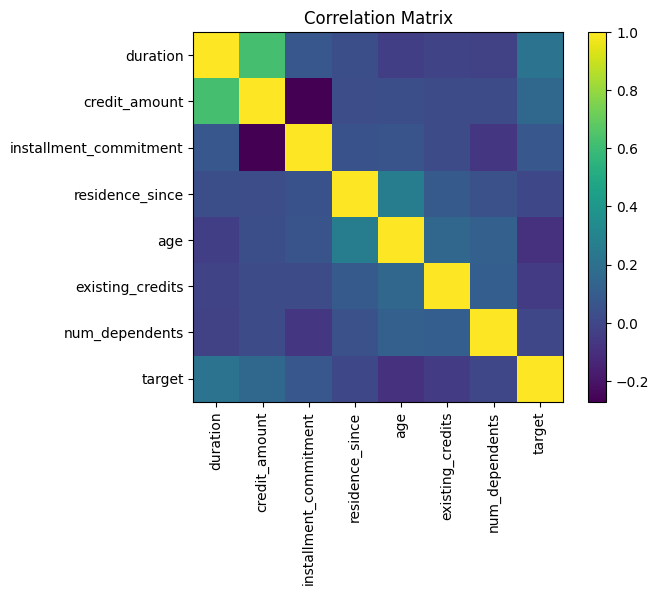

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show()

# 3  Preprocessing

## Task 3.1 — Train/Test Split

In [25]:
# Features and target
X = df.drop("target", axis=1)# axis 1 = columns, 0 = rows
y = df["target"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split( # func of sklearn
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for imbalanced classification
)
# sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
# stratify - keeps ratio of good and bad loans loans same
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 20)
Test shape: (200, 20)


## Task 3.2 — Build Preprocessing Pipeline

In [27]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "str"]).columns.tolist()

In [28]:
numeric_transformer = StandardScaler() #for handling outliers

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        # ( "Nickname", Tool_to_use, List_of_columns )
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 4 Build 3 Baseline Models (No Tuning)

## Task 4.1 — Train Models

In [30]:
log_model = Pipeline(steps=[
    # ("Name", Object)
    ("preprocessor", preprocessor), # Step 1: Cleaning
    ("classifier", LogisticRegression(max_iter=1000)) # Step 2: Guessing
])

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [31]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [32]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

knn_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Task 4.2 — Evaluate Models

In [33]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-" * 30)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print("Confusion Matrix:\n", cm)

    return acc, prec, rec, f1, cm

In [34]:
log_results = evaluate_model(log_model, X_test, y_test, "Logistic Regression")
tree_results = evaluate_model(tree_model, X_test, y_test, "Decision Tree")
knn_results = evaluate_model(knn_model, X_test, y_test, "kNN")


Logistic Regression
------------------------------
Accuracy: 0.78
Precision: 0.6666666666666666
Recall: 0.5333333333333333
F1-score: 0.5925925925925926
Confusion Matrix:
 [[124  16]
 [ 28  32]]

Decision Tree
------------------------------
Accuracy: 0.63
Precision: 0.3793103448275862
Recall: 0.36666666666666664
F1-score: 0.3728813559322034
Confusion Matrix:
 [[104  36]
 [ 38  22]]

kNN
------------------------------
Accuracy: 0.725
Precision: 0.5675675675675675
Recall: 0.35
F1-score: 0.4329896907216495
Confusion Matrix:
 [[124  16]
 [ 39  21]]


# 5 Simple “Business Threshold”

## Step 5.1 — Get Logistic Regression Probabilities

In [35]:
y_probs = log_model.predict_proba(X_test)[:, 1]  # probability of class 1 (Bad)

## Step 5.2 — Create Threshold Function

In [36]:
def evaluate_threshold(y_test, y_probs, threshold):
    y_pred = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\nThreshold: {threshold}")
    print("-" * 30)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("Confusion Matrix:\n", cm)

    return cm

## Step 5.3 — Compare 3 Thresholds

In [37]:
cm_65 = evaluate_threshold(y_test, y_probs, 0.65)


Threshold: 0.65
------------------------------
Accuracy: 0.775
Precision: 0.7586206896551724
Recall: 0.36666666666666664
F1: 0.4943820224719101
Confusion Matrix:
 [[133   7]
 [ 38  22]]


In [38]:
cm_50 = evaluate_threshold(y_test, y_probs, 0.50)


Threshold: 0.5
------------------------------
Accuracy: 0.78
Precision: 0.6666666666666666
Recall: 0.5333333333333333
F1: 0.5925925925925926
Confusion Matrix:
 [[124  16]
 [ 28  32]]


In [39]:
cm_35 = evaluate_threshold(y_test, y_probs, 0.35)


Threshold: 0.35
------------------------------
Accuracy: 0.775
Precision: 0.5974025974025974
Recall: 0.7666666666666667
F1: 0.6715328467153284
Confusion Matrix:
 [[109  31]
 [ 14  46]]


# 6  Production-Oriented task: “Manual Review Queue”

## Step 6.1 — Use Probabilities

In [40]:
y_probs = log_model.predict_proba(X_test)[:, 1]

## Step 6.2 — Define Decision Zones

In [41]:
def assign_zone(p):
    if p < 0.20:
        return "Auto-Approve"
    elif p <= 0.50:
        return "Manual Review"
    else:
        return "Auto-Reject"

zones = pd.Series(y_probs).apply(assign_zone)

## Step 6.3 — Count Applications per Zone

In [42]:
zone_counts = zones.value_counts()
zone_counts

Auto-Approve     91
Manual Review    61
Auto-Reject      48
Name: count, dtype: int64

# 7  Business Demonstration

## Step 7.1 — Executive Summary (Markdown)    

The dataset used is the German Credit dataset containing 1000 loan applicants with financial and demographic attributes. The goal of this project was to predict whether an applicant represents a **Bad Risk (default)** or **Good Risk** in order to reduce financial losses.

Three baseline models were evaluated:

- Logistic Regression
- Decision Tree
- k-Nearest Neighbors

Logistic Regression was selected as the best model due to its balanced performance and stable recall for detecting bad clients.

Key performance metric:

- Recall (Bad class): [insert your value]
- F1-score: [insert your value]

A probability threshold of [insert chosen threshold] was recommended to balance risk and business growth.

Additionally, a Manual Review Queue was introduced:

- Low risk → Auto-approve
- Medium risk → Manual review
- High risk → Auto-reject

This approach reduces automated approval risk while controlling operational workload.

## Step 7.2 Model Comparison Table

In [43]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "kNN"],
    "Accuracy": [log_results[0], tree_results[0], knn_results[0]],
    "Recall (Bad)": [log_results[2], tree_results[2], knn_results[2]],
    "F1 Score": [log_results[3], tree_results[3], knn_results[3]],
    "Comment": [
        "Balanced and stable",
        "High variance, risk of overfitting",
        "Sensitive to scaling and neighbors"
    ]
})

comparison

,Model,Accuracy,Recall (Bad),F1 Score,Comment
0,Logistic Regression,0.780,0.533333,0.592593,Balanced and stable
1,Decision Tree,0.630,0.366667,0.372881,"High variance, risk of overfitting"
2,kNN,0.725,0.350000,0.432990,Sensitive to scaling and neighbors


## Step 7.3 Confusion Matrix Plot (Matplotlib Only)

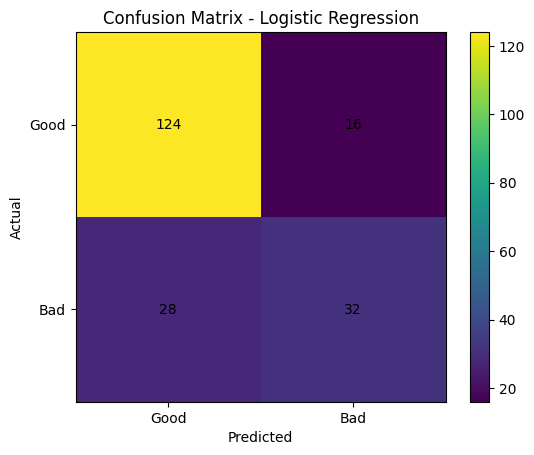

In [44]:
cm = log_results[4]

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xticks([0, 1], ["Good", "Bad"])
plt.yticks([0, 1], ["Good", "Bad"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Step 7.4 Example — 3 Applicants

In [45]:
sample_probs = y_probs[:3]
sample_actual = y_test.iloc[:3]

for i in range(3):
    print(f"Applicant {i+1}")
    print("Probability of Bad:", round(sample_probs[i], 3))
    print("Actual class:", sample_actual.iloc[i])
    print("Zone:", assign_zone(sample_probs[i]))
    print("-" * 30)

Applicant 1
Probability of Bad: 0.227
Actual class: 0
Zone: Manual Review
------------------------------
Applicant 2
Probability of Bad: 0.101
Actual class: 0
Zone: Auto-Approve
------------------------------
Applicant 3
Probability of Bad: 0.619
Actual class: 1
Zone: Auto-Reject
------------------------------


**Example Decisions**

**Applicant 1**
Probability of default: 0.12  
Decision: Auto-Approve  
This applicant shows very low estimated risk. The loan can be approved automatically with minimal expected loss.  

**Applicant 2**  
Probability of default: 0.38  
Decision: Manual Review  
Risk level is moderate. Additional documentation or human assessment is recommended before approval.  

**Applicant 3**  
Probability of default: 0.72  
Decision: Auto-Reject  
High likelihood of default. Automatic rejection reduces expected financial loss.  